# **A vetorização _Word-Embedding_**
<font size=3>

*Word-embeddings* representam palavras/tokens como **vetores densos** compostos por números racionais, permitindo representações com **dimensões significativamente menores** em comparação com a codificação *one-hot*, BoW ou TF-IDF. Esses vetores são **aprendidos durante o treinamento** ou derivados de embeddings pré-treinados, que são especialmente úteis para conjuntos de dados menores.

Por exemplo, uma palavra representada em codificação *one-hot* como [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0] pode ser uma forma *embedding* ("embutida") como [0.245 -0.183 0.834]. O tamanho de um vetor *one-hot* corresponde ao **tamanho do vocabulário** ($\mathtt{vocab\_size}$), enquanto o tamanho de um vetor *embedding* é determinado pela **dimensão do _embedding_** ($\mathtt{embed\_dim}$), um hiperparâmetro pré-definido.



## **1. Como essa vetorização funciona na prática:**
<font size=3>

1. Importamos o *corpus*;

2. Transformamos cada sentença em uma lista de $\mathtt{token\_IDs}$:
    - Depois que todos os *tokens* são catalogados na lista de vocabulário, cada *token* de uma sentença é substituído pelo índice de sua posição da lista de vocabulário.
    <br>

3. Realizamos o *word-embedding*:
    - Inicializamos randomicamente a **matriz _embedding_**, $\,W_e \in \mathbb{R}^{\mathtt{vocab\_size} \times \mathtt{emded\_dim}}\,$;
    - Cada linha de $W_e$ irá corresponder a um ***token* vetorizado**.
    - Durante o treinamento da rede neural, *weights*, *bias* e os elementos da matriz *embedding* são ajustados **de modo a extrair o máximo de _features_ possíveis** das sentenças.


In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [2]:
import numpy as np
from keras import layers

In [3]:
# 1. importando o corpus:
corpus = ["Beautiful is better than ugly",
          "Explicit is better than implicit",
          "Simple is better than complex",
          "Complex is better than complicated",
          "Flat is better than nested",
          "Sparse is better than dense",
          "Readability counts",
          "Special cases aren't special enough to break the rules",
          "Although practicality beats purity",
          "Errors should never pass silently",
          "Unless explicitly silenced",
          "In the face of ambiguity, refuse the temptation to guess",
          "There should be one -- and preferably only one -- obvious way to do it",
          "Although that way may not be obvious at first unless you're Dutch",
          "Now is better than never",
          "Although never is often better than right now",
          "If the implementation is hard to explain, it's a bad idea",
          "If the implementation is easy to explain, it may be a good idea",
          "Namespaces are one honking great idea -- let's do more of those!"]


In [4]:
# 2. transformando cada sentença em uma lista de token-IDs:

vocab_size = None # captura o tamanho máximo do vocabulário
max_len = 7 # tamanho máximo da sentença

vectorizer = layers.TextVectorization(max_tokens=vocab_size,
                                     standardize='lower_and_strip_punctuation',
                                     split='whitespace',
                                     output_mode='int',
                                     output_sequence_length=max_len)

vectorizer.adapt(corpus)

vocab = vectorizer.get_vocabulary()
vocab_size = vectorizer.vocabulary_size()

# obtendo as listas de tokens-IDs:
token_ids = vectorizer(corpus)

# [UNK] = unknown word
print("Tamanho do vocabulário:", vocab_size)
print("Tokens do vocabulário:", vocab)

Tamanho do vocabulário: 82
Tokens do vocabulário: ['', '[UNK]', np.str_('is'), np.str_('than'), np.str_('better'), np.str_('to'), np.str_('the'), np.str_('one'), np.str_('never'), np.str_('idea'), np.str_('be'), np.str_('although'), np.str_('way'), np.str_('unless'), np.str_('special'), np.str_('should'), np.str_('of'), np.str_('obvious'), np.str_('now'), np.str_('may'), np.str_('it'), np.str_('implementation'), np.str_('if'), np.str_('explain'), np.str_('do'), np.str_('complex'), np.str_('a'), np.str_('youre'), np.str_('ugly'), np.str_('those'), np.str_('there'), np.str_('that'), np.str_('temptation'), np.str_('sparse'), np.str_('simple'), np.str_('silently'), np.str_('silenced'), np.str_('rules'), np.str_('right'), np.str_('refuse'), np.str_('readability'), np.str_('purity'), np.str_('preferably'), np.str_('practicality'), np.str_('pass'), np.str_('only'), np.str_('often'), np.str_('not'), np.str_('nested'), np.str_('namespaces'), np.str_('more'), np.str_('lets'), np.str_('its'), np.

In [5]:
print("Zen of Python indexado:")
token_ids

Zen of Python indexado:


<tf.Tensor: shape=(19, 7), dtype=int64, numpy=
array([[74,  2,  4,  3, 28,  0,  0],
       [64,  2,  4,  3, 54,  0,  0],
       [34,  2,  4,  3, 25,  0,  0],
       [25,  2,  4,  3, 71,  0,  0],
       [60,  2,  4,  3, 48,  0,  0],
       [33,  2,  4,  3, 69,  0,  0],
       [40, 70,  0,  0,  0,  0,  0],
       [14, 72, 78, 14, 66,  5, 73],
       [11, 43, 75, 41,  0,  0,  0],
       [65, 15,  8, 44, 35,  0,  0],
       [13, 63, 36,  0,  0,  0,  0],
       [53,  6, 62, 16, 81, 39,  6],
       [30, 15, 10,  7, 80, 42, 45],
       [11, 31, 12, 19, 47, 10, 17],
       [18,  2,  4,  3,  8,  0,  0],
       [11,  8,  2, 46,  4,  3, 38],
       [22,  6, 21,  2, 56,  5, 23],
       [22,  6, 21,  2, 67,  5, 23],
       [49, 79,  7, 55, 58,  9, 51]])>

In [6]:
# 3. realizando o word-embedding:
embed_dim = 3

embedding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)


# Para que possamos visualizar a matriz embedding W_e, precisamos inicializar
# o objeto `embedding` com o formato da entrada (sentenças vetorizadads):
embedding.build(input_shape=(token_ids.shape))


# imprimindo a matriz embedding W_e - uma matriz do formato (vocab_size, embed_dim):
W_e = embedding.weights[0].numpy()

print("Matrix embedding (W_e):", W_e.shape, "\n")
print(W_e)

Matrix embedding (W_e): (82, 3) 

[[-2.0961976e-02 -1.3430584e-02 -4.6198249e-02]
 [-3.6431503e-02  2.1234725e-02  4.0252898e-02]
 [-1.1046976e-04 -3.3098221e-02 -2.6158929e-02]
 [ 3.2834634e-03  3.8062777e-02 -3.0843532e-02]
 [-9.2374794e-03  3.3863489e-02 -3.7511874e-02]
 [-4.0606223e-02  2.2568587e-02  1.9432966e-02]
 [ 4.7786843e-02 -3.1801820e-02  2.8833222e-02]
 [-4.4448521e-02 -3.3383861e-02 -2.1149404e-03]
 [-4.4260778e-02 -3.5658240e-02 -2.8841389e-02]
 [-2.5785113e-02  1.0380946e-02  3.8318504e-02]
 [-3.3521283e-02 -4.5816768e-02  1.9272301e-02]
 [-3.4567036e-02 -3.8574111e-02 -3.9302312e-02]
 [ 4.5312237e-02 -3.7379779e-02  3.0130472e-02]
 [-1.7105006e-02 -2.9946912e-02 -3.2065380e-02]
 [ 4.0911522e-02 -1.5011191e-02 -9.5653757e-03]
 [ 4.9096230e-02 -2.6601588e-02 -1.8654943e-02]
 [-2.9605329e-02 -1.0796510e-02  4.4891145e-02]
 [ 3.6766123e-02  2.9104579e-02  2.0541739e-02]
 [-1.1552215e-02 -6.6738836e-03 -1.1387326e-02]
 [-2.9533077e-02 -1.6389169e-02  2.1448705e-02]
 [-2.3

In [7]:
# obtendo os tokens vetorizados:
embed_tokens = embedding(token_ids)

In [8]:
# vamos visualizar uma sentença vetorizada:

i = 0
print(f"- Sentença:\n{corpus[i]}\n")
print(f"- Token-IDs:\n{token_ids[i]}\n")
print(f"- Embedded tokens:\n{embed_tokens[0].numpy()}")

- Sentença:
Beautiful is better than ugly

- Token-IDs:
[74  2  4  3 28  0  0]

- Embedded tokens:
[[ 0.03798983 -0.0478069  -0.03880116]
 [-0.00011047 -0.03309822 -0.02615893]
 [-0.00923748  0.03386349 -0.03751187]
 [ 0.00328346  0.03806278 -0.03084353]
 [ 0.02084336  0.02019036 -0.0271499 ]
 [-0.02096198 -0.01343058 -0.04619825]
 [-0.02096198 -0.01343058 -0.04619825]]


<font size=3>

> Observe acima que o $\mathtt{token\_IDs}$ **são** os índices das linhas da matriz embedding $W_e$. Assim, cada *token* é mapeada por um vetor de tamanho $\mathtt{embed\_dim}$.

## **2. _Word-embeddings_ pré-treinadas:**
<font size=3>

Ao trabalhar com um **pequeno conjunto de dados** ou com o objetivo de reduzir os custos computacionais de treinamento, **_word-embeddings_ pré-treinados** podem ser altamente benéficos. [*Word-embeddings* pré-treinados](https://keras.io/examples/nlp/pretrained_word_embeddings/) populares incluem [Word2vec](https://code.google.com/archive/p/word2vec/) e [Global Vectors for Word Representation (GloVe)](https://nlp.stanford.edu/projects/glove/). Neste exemplo, vetorizaremos nosso corpus *Zen of Python* usando *embeddings* do **GloVe**.

Para começar, precisamos baixar o conjunto de dados GloVe usando a célula abaixo. O arquivo zip baixado contém embeddings com quatro representações dimensionais diferentes (50D, 100D, 200D e 300D). Para esta tarefa, nos concentraremos em $\mathtt{embed\_dim = 100}$.

In [9]:
#!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
#!unzip -q glove.6B.zip

In [10]:
# obtendo os vetores de tokens:
embed_dim = 100
embed_dict = {}

with open(f"./dataset/glove.6B.{embed_dim}d.txt") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embed_dict[word] = coefs

print(f"Temos {len(embed_dict)} palavras vetorizadas.\n")

print('Vetorização da palavra "talk":\n', embed_dict["talk"])

Temos 400000 palavras vetorizadas.

Vetorização da palavra "talk":
 [-7.9761e-02  1.9551e-01  3.0579e-01 -2.1571e-01 -4.9017e-01  4.6350e-01
 -1.5171e-01 -1.6002e-01  1.3081e-01 -6.5718e-01 -1.1343e-01  1.0231e-01
  1.1583e-01  2.0241e-03  1.8107e-01 -1.8263e-01 -4.2386e-01  5.6726e-02
 -3.0419e-01  1.5828e-01 -1.1820e-01  1.8624e-01 -5.2731e-01 -5.9154e-01
  7.1546e-02  1.9633e-01 -4.9147e-02 -3.3004e-01  5.0489e-01  5.1138e-01
 -5.0726e-01  7.9255e-01  1.7890e-01  3.5001e-01 -7.2015e-02  8.9293e-01
 -2.7286e-01 -5.7761e-01  1.8615e-01 -9.8489e-02 -6.1398e-01  6.1104e-02
 -3.3847e-01 -2.9190e-01 -7.1794e-01 -3.7329e-01 -3.2193e-01 -3.8184e-01
  4.9009e-02 -1.2856e+00  3.1266e-02  1.2953e-01  1.1391e-01  6.9458e-01
  3.3839e-01 -2.1965e+00  8.4632e-02  7.6947e-02  9.7508e-01  3.2743e-01
  2.8664e-01  7.9778e-01 -4.9729e-01 -1.1200e+00  9.1580e-01  8.9064e-02
  1.1378e+00  3.3187e-01 -1.8245e-01  1.7541e-01  9.8961e-02 -3.9566e-01
 -4.1590e-01 -7.4777e-01 -4.6913e-01  3.8674e-01  2.7161

<font size=3>

Não precisamos considerar todos os pesos do *embedding* do GloVe, que têm o formato (400000, 100). Em vez disso, se quisermos resolver a tarefa usando apenas o corpus _Zen of Python_, podemos simplesmente nos concentrar em seu vocabulário. Isso nos permitirá obter um array com o formato (82, 100).

In [11]:
hits = 0
misses = 0

# definindo um dicionário de vocabulário do corpus:
vocab_dict = dict(zip(vocab, range(len(vocab))))

# preparando os pesos (weights) da matriz embedding:
embedding_weights = np.zeros((vocab_size, embed_dim))

for word, i in vocab_dict.items():
    embedding_vector = embed_dict.get(word)
    if embedding_vector is not None:

        '''
        Palavras que não estão nos índices do embedding serão definidas como zero.
        Isso também se aplica a representação de preenchimento (padding) e "out of vocabulary" (OOV).
        '''

        embedding_weights[i] = embedding_vector
        hits += 1

    else:
        misses += 1

print(f"Converted {hits} words ({misses} misses)")

Converted 80 words (2 misses)


In [12]:
# definindo o word-embeding pré-treinado:

embedding = layers.Embedding(input_dim=vocab_size,
                             output_dim=embed_dim,
                             weights=[embedding_weights],
                             trainable=False)

'''
Como estamos usando weights pré-treinados da matriz embedding, não queremos
perdê-los durante o treinamento da NN. Portanto, para os embedding weights,
nós definimos `trainable=False`.
'''

print(f"weights array:{embedding.weights[0].shape}")

# get the embedded tokens:
embed_tokens = embedding(token_ids)

weights array:(82, 100)


In [13]:
# vamos visualizar uma sentença vetorizada:

i = 0
print(f"- Sentença:\n{corpus[i]}\n")
print(f"- Token-IDs:\n{token_ids[i]}\n")
print(f"- Embedded tokens:\n{embed_tokens[0].numpy()}")

- Sentença:
Beautiful is better than ugly

- Token-IDs:
[74  2  4  3 28  0  0]

- Embedded tokens:
[[-0.18173    0.49759    0.46326    0.22507    0.46379    0.70062
  -0.55155    0.79148   -0.18582    0.19755    0.19881    0.09037
   0.02684    0.036921   0.25217    0.30879    0.33164    0.2714
  -0.12808    1.1721    -0.072969   0.34904    0.11161   -0.36056
   0.59628    0.42417   -0.69904   -0.19768   -0.35599   -0.23141
  -0.38503   -0.12665    0.77121   -0.37397    0.59642   -0.24416
  -0.25387   -0.065911   0.21035   -0.83429    0.28604   -0.022707
   0.06746    0.088804   0.23424    0.20475    0.085396   0.55393
   0.34153   -0.095455  -0.19291   -0.55262    1.0229     0.3866
  -0.24254   -2.3519     0.43561    1.1172     0.77358   -0.73769
  -0.35302    1.6699    -0.63955   -0.39244    0.56454   -0.27873
   0.9252    -0.13997   -0.096213  -1.1242     0.49031    0.36918
   0.41195   -0.038159   0.84123    0.24619    0.081767   0.07483
   0.44646   -0.19423    0.013369   0.37712 

<font size=3>
<br>
    
Uma vantagem fundamental de *word-embeddings* é sua capacidade de capturar as relações semânticas entre as palavras no **espaço de _embedding_**. Por exemplo, sinônimos tendem a ter representações vetoriais semelhantes, resultando em distâncias geométricas mais próximas. Isso permite relações intuitivas, como "cachorro" estar mais próximo de "lobo", e "gato" de "tigre".


In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [15]:
# selecionando palabras da matriz de embedding do GloVe:
word_vectors = []
words = ['man', 'woman', 'king', 'queen']

for word in words:
    if word in embed_dict:
        word_vectors.append(embed_dict[word])
    else:
        print(f"Palavra '{word}' não encontrada no GloVe!")

word_vectors = np.array(word_vectors)

word_vectors.shape

(4, 100)

In [16]:
# redução de dimensionalidade para plote do espaço vetorial:
pca = PCA(n_components=2)

vectors_2D = pca.fit_transform(word_vectors)

vectors_2D.shape

(4, 2)

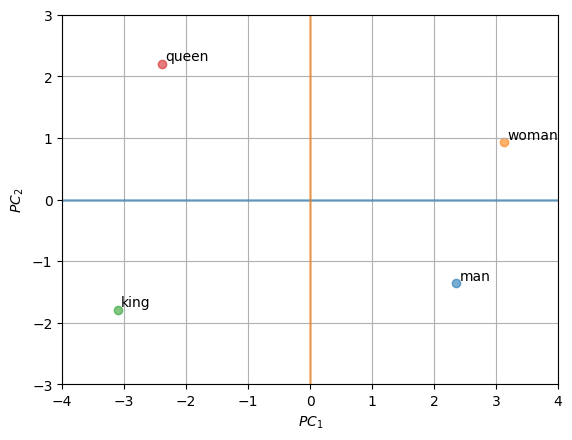

In [17]:
for word, vec in zip(words, vectors_2D):
    plt.scatter(*vec, alpha=0.6)
    plt.text(*vec+0.05, word)

plt.axhline(c="tab:blue", lw=2, alpha=0.5)
plt.axvline(c="tab:orange", lw=2, alpha=0.5)
plt.xlim(-4, 4)
plt.ylim(-3, 3)
plt.xlabel("$PC_1$")
plt.ylabel("$PC_2$")
plt.grid()
plt.show()

<font size=3>

Essa "distância geométrica" é tipicamente medida pela similaridade de cosseno,
$$
    \cos\theta = \frac{\vec a\cdot \vec b}{|\vec a||\vec b|} \, ,
$$
onde $\theta \in [-1,\, +1]$ varia de vetores opostos (-1) a semelhantes (+1).

O conjunto de dados GloVe inclui palavras de vários idiomas, o que significa que algumas correlações opostas podem surgir entre palavras de diferentes idiomas. Abaixo, alguns exemplos de similaridade de cosseno usando apenas palavras em inglês.

In [18]:
def cosine_similarity(a, b):

    A = np.linalg.norm(a)
    B = np.linalg.norm(b)

    return np.dot(a, b)/(A*B)

print("(good vs nice):", cosine_similarity(embed_dict["good"], embed_dict["nice"]))
print("(dog vs universities):", cosine_similarity(embed_dict["dog"], embed_dict["universities"]))
print("(read vs colonizer):", cosine_similarity(embed_dict["read"], embed_dict["colonizer"]))

(good vs nice): 0.73124516
(dog vs universities): 0.002391997
(read vs colonizer): -0.2923915


<font size=3>
<br>
    
Os resultados da similaridade de cosseno ilustram perfeitamente como os *embeddings* capturam o significado contextual da linguagem. O valor positivo alto ($0.73$) entre **"_good_"** e **"_nice_"** demonstra que o modelo aprendeu a forte relação de sinonímia entre elas, posicionando seus vetores em direções muito próximas. Em nítido contraste, o valor quase zero ($0.002$) para **"_dog_"** e **"_universities_"** mostra que o modelo os considera semanticamente irrelevantes (ortogonais), pois não compartilham contexto. O mais sutil é o valor negativo ($-0.29$) entre **"_read_"** e **"_colonizer_"**, que indica não apenas uma falta de relação, mas um contraste contextual.

## **3. [Extra] Camada linear _vs_ camada _embedding_:**
<font size=3>

Diz-se que as **camadas de _embeddings_** funcionam de forma semelhante às **camadas lineares**. Para entender melhor como funciona a incorporação de palavras, vamos comparar suas semelhanças e diferenças.

<font size=3>

Uma camada *embedding* se comporta de forma semelhante a uma camada linear, pois não possui uma função de ativação (já que é linear), mas não inclui um vetor *bias*. Ao considerar a entrada como um **vetor _one-hot_** $a_0^i$, a saída da camada linear (para $b_1^i = 0$) é dado por,
\begin{align}
     a_0^i\;\; W^{ij} &= a_1^j \, ,\\\\
     \begin{pmatrix}
     0 & 1 & 0 & 0
     \end{pmatrix}
     \begin{pmatrix}
         w_{00} & w_{01} & w_{02} \\
         w_{10} & w_{11} & w_{12} \\
         w_{20} & w_{21} & w_{22} \\
         w_{30} & w_{31} & w_{32}
     \end{pmatrix}
     &=
     \begin{pmatrix}
         w_{10} & w_{11} & w_{12}
     \end{pmatrix}  \, ,
\end{align}
onde os índices $\; i \in [0,\, \mathtt{vocab\_size})$ e $\; j \in [0,\, \mathtt{embed\_dim})$. Já, a camada *embedding* funciona da seguinte forma,
\begin{align}
    \delta^{ki}\;\;W^{ij} &= a_1^j\, ,\\\\
     \begin{pmatrix}
         w_{00} & w_{01} & w_{02} \\
         [w_{10} & w_{11} & w_{12}] \\
         w_{20} & w_{21} & w_{22} \\
         w_{30} & w_{31} & w_{32}
     \end{pmatrix}
      &\Rightarrow
     \begin{pmatrix}
         w_{10} & w_{11} & w_{12}
     \end{pmatrix} \, ,
\end{align}
onde $\delta^{kj} = [1,\; k=j;\quad 0,\; k\neq j]$, e $k = 1$ é um $\mathtt{token\_id}$, que seleciona o vetor $(w_{10}\;\; w_{11}\;\;  w_{12})$ sem precisar de uma codificação *one-hot*.

### **3.1 Camada linear:**

In [19]:
# vamos considerar um corpus com vocabulário de tamanho:
vocab_size = 10

# e que iremos fazer o embedding em uma matriz de dimensão:
embed_dim = 5

# também iremos considerar a seguinte lista de token-IDs:
token_ids = np.array([3, 8, 2, 5, 0])

'''
Note que ID = 0 em tokens-IDs representa o preenchimento (padding).
Para comparar camada linear vs embedding, o tamnho da entrada da camada (max-len)
precisa ter o mesmo tamanho de embed_dim.
'''

max_len = token_ids.size

assert max_len == embed_dim

In [20]:
# vetorização one-hot do token-IDs:
onehot = layers.CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot")(token_ids)

for ID, hot in zip(token_ids, onehot):
    print(f"{ID}: {hot}")


3: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
8: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
2: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
0: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [21]:
# definindo a camada linear:
linear = layers.Dense(units=max_len, bias_initializer="zeros")
linear.build(input_shape=onehot.shape) # incializando os weights

weights = linear.weights[0].numpy()

print("- Weights lineares:\n", weights, end="\n\n")
print("- Saída da camada linear:\n", linear(onehot).numpy())

- Weights lineares:
 [[-0.08167255  0.17746043 -0.6106632  -0.15108892 -0.48726803]
 [-0.29526278 -0.3069375   0.0424794   0.32035035 -0.36710748]
 [-0.09039295 -0.6247549   0.11884445 -0.22536221 -0.48429948]
 [ 0.24223536  0.52863747 -0.24730733  0.45159584  0.3239426 ]
 [ 0.36457604  0.2985506  -0.22608209  0.6144907  -0.52952623]
 [ 0.06096345 -0.29150212 -0.21288562 -0.47493982  0.177822  ]
 [ 0.35184193  0.5104131   0.6308786  -0.42637968 -0.50051063]
 [-0.32638326 -0.24062192 -0.36895525 -0.08896351 -0.5978354 ]
 [-0.58698446  0.31802636 -0.61437166 -0.2642387  -0.45219964]
 [ 0.05883324 -0.0398438  -0.06467724 -0.22055596 -0.05286819]]

- Saída da camada linear:
 [[ 0.24223536  0.52863747 -0.24730733  0.45159584  0.3239426 ]
 [-0.58698446  0.31802636 -0.61437166 -0.2642387  -0.45219964]
 [-0.09039295 -0.6247549   0.11884445 -0.22536221 -0.48429948]
 [ 0.06096345 -0.29150212 -0.21288562 -0.47493982  0.177822  ]
 [-0.08167255  0.17746043 -0.6106632  -0.15108892 -0.48726803]]


### **3.2 Camada _embedding_:**
<font size=3>

Aqui, a camada *embedding* seleciona as linhas de $\mathtt{weights}$ usando $\mathtt{token\_ids}$, sem a necessidade de multiplicação de matriz da codificação *one-hot*.

In [22]:
# definindo a camada embedding usando os mesmos weights da camada linear, para comparação:
embedding = layers.Embedding(input_dim=vocab_size, output_dim=max_len, weights=[weights])

print("- Weights do embedding:\n", embedding.weights[0].numpy(), end="\n\n")
print("- Saída da camada de embedding:\n", embedding(token_ids).numpy())

- Weights do embedding:
 [[-0.08167255  0.17746043 -0.6106632  -0.15108892 -0.48726803]
 [-0.29526278 -0.3069375   0.0424794   0.32035035 -0.36710748]
 [-0.09039295 -0.6247549   0.11884445 -0.22536221 -0.48429948]
 [ 0.24223536  0.52863747 -0.24730733  0.45159584  0.3239426 ]
 [ 0.36457604  0.2985506  -0.22608209  0.6144907  -0.52952623]
 [ 0.06096345 -0.29150212 -0.21288562 -0.47493982  0.177822  ]
 [ 0.35184193  0.5104131   0.6308786  -0.42637968 -0.50051063]
 [-0.32638326 -0.24062192 -0.36895525 -0.08896351 -0.5978354 ]
 [-0.58698446  0.31802636 -0.61437166 -0.2642387  -0.45219964]
 [ 0.05883324 -0.0398438  -0.06467724 -0.22055596 -0.05286819]]

- Saída da camada de embedding:
 [[ 0.24223536  0.52863747 -0.24730733  0.45159584  0.3239426 ]
 [-0.58698446  0.31802636 -0.61437166 -0.2642387  -0.45219964]
 [-0.09039295 -0.6247549   0.11884445 -0.22536221 -0.48429948]
 [ 0.06096345 -0.29150212 -0.21288562 -0.47493982  0.177822  ]
 [-0.08167255  0.17746043 -0.6106632  -0.15108892 -0.48726

<font size=3>
<br>
    
Assim, mostramos os **mesmos resultados** de saída de ambos os tipos de camadas!

## __Referências:__
<font size=3>
    
 - [Deep Learning with Python](https://books.google.com.br/books/about/Deep_Learning_with_Python.html?id=Yo3CAQAACAAJ&redir_esc=y);
 - [Build a Large Language Model From Scratch](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb);
 - [Understanding word-embedding with Keras](https://medium.com/@hsinhungw/understanding-word-embeddings-with-keras-dfafde0d15a4).
